In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**End-to-End ML Pipeline**: Tesla Deliveries Dataset (2015-2025)

**Covers**: Preprocessing, EDA, Feature Engineering, Regression Modeling,Hyperparameter Tuning, and Time Series Forecasting

In [18]:
# Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [7]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


**Output description:** Shows the first 5 rows of the dataset so we can understand columns and sample values.

In [8]:
# 2. Basic Dataset Information

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.info()

Dataset Shape: (2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 26

**Output description:** Shows number of rows, columns, data types, and missing values.

In [9]:
# 3. Data Preprocessing

df = df.drop_duplicates()

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)

cat_cols = ["Region", "Model", "Source_Type"]

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


**Output description:** Removes duplicate rows, creates a Date column, and converts categorical columns into numeric form.

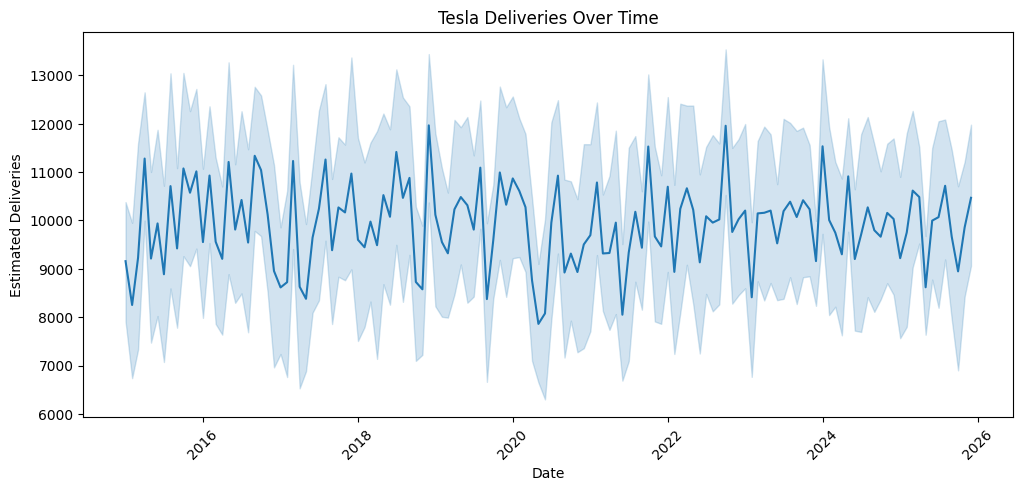

In [10]:
# 4. Exploratory Data Analysis - Deliveries Over Time

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="Date", y="Estimated_Deliveries")
plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)
plt.show()

**Output description:** Shows how Tesla deliveries changed over time from 2015 to 2025.

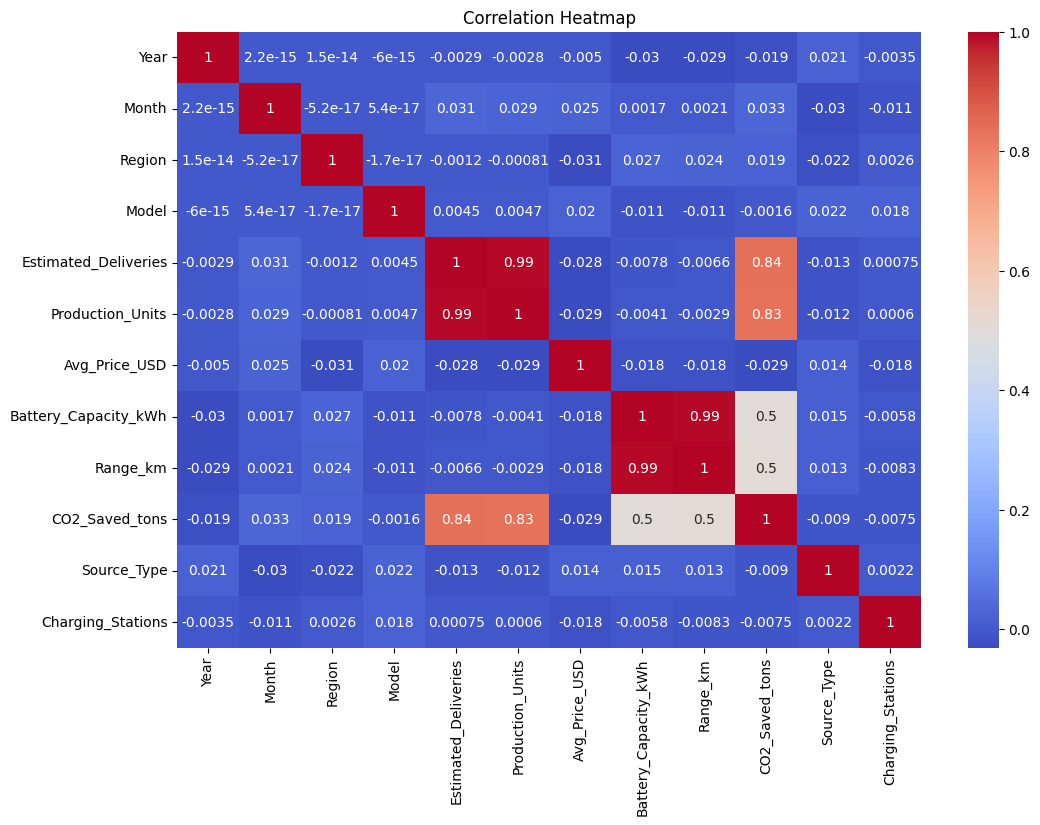

In [11]:
# 5. Correlation Heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

**Output description:** Shows relationships between numerical columns. Higher positive/negative values show stronger relation

In [26]:
# 6. Feature Engineering

df["Quarter"] = ((df["Month"] - 1) // 3) + 1

df["Price_per_Range"] = df["Avg_Price_USD"] / df["Range_km"]

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Price_per_Range,Production_to_Delivery_Ratio
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,2,131.923679,1.015641
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,1,142.022032,1.096655
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,1,245.598583,1.092498
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,1,125.414199,1.115332
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,4,173.747020,1.093987


**Output description:** Adds new useful columns that may improve model prediction.

In [27]:
# 7. Select Features and Target

X = df[
    [
        "Year",
        "Month",
        "Quarter",
        "Region",
        "Model",
        "Production_Units",
        "Avg_Price_USD",
        "Battery_Capacity_kWh",
        "Range_km",
        "CO2_Saved_tons",
        "Charging_Stations",
        "Source_Type",
        "Price_per_Range"
    ]
]

y = df["Estimated_Deliveries"]

print("Feature Data Shape:", X.shape)
print("Target Data Shape:", y.shape)

Feature Data Shape: (2640, 13)
Target Data Shape: (2640,)


**Output description:** Separates input features X and target output y.

In [28]:
# 8. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2112, 13)
Testing Data: (528, 13)


**Output description:** Splits data into 80% training and 20% testing.

In [29]:
# 9. Train Regression Model

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**Output description:** Trains a Random Forest regression model and predicts deliveries on test data.

In [30]:
# 10. Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance
MAE: 326.30125
RMSE: 411.9393671890943
R2 Score: 0.9886159424320333


**Output description:**
The Random Forest Regression model achieved strong predictive performance with a Mean Absolute Error (MAE) of 326.30, indicating that predictions differ from the actual delivery values by approximately 326 vehicles on average. The Root Mean Squared Error (RMSE) of 411.94 reflects a low prediction error while penalizing larger mistakes more heavily. The R² Score of 0.9886 indicates that the model explains 98.86% of the variance in Tesla deliveries, demonstrating that it accurately captures the underlying relationship between the input features and the target variable.

In [31]:
# 11. Hyperparameter Tuning

params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Tuned R2 Score:", r2_score(y_test, best_pred))

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Tuned R2 Score: 0.9886090407732363


**Output Description:** GridSearchCV was used to optimize the Random Forest hyperparameters. The best combination was 100 decision trees (n_estimators=100), a maximum tree depth of 20 (max_depth=20), and a minimum of 5 samples required to split a node (min_samples_split=5). The tuned model achieved an R² score of 0.9886, which is nearly identical to the default Random Forest model, indicating that the default parameters were already well-suited for this dataset.

In [32]:
# 12. Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
5,Production_Units,0.991255
9,CO2_Saved_tons,0.002162
8,Range_km,0.001126
12,Price_per_Range,0.001008
6,Avg_Price_USD,0.001003
10,Charging_Stations,0.000993
0,Year,0.000716
1,Month,0.000533
4,Model,0.000376
3,Region,0.000326


**Output description:** Shows which features contributed most to delivery prediction.

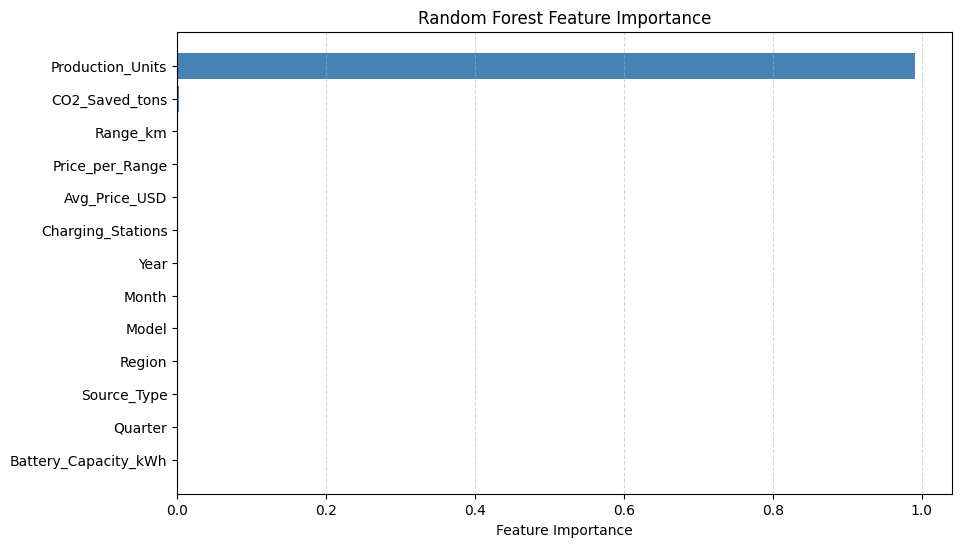

In [40]:
plt.figure(figsize=(10,6))

importance = importance.sort_values("Importance")

plt.barh(
    importance["Feature"],
    importance["Importance"],
    color="steelblue"
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

**Output Description:** The feature importance analysis shows that Production_Units is the most influential feature, contributing approximately 99.13% to the model's predictions. This is expected because the number of vehicles produced directly affects the number of vehicles delivered. Other features such as CO2_Saved_tons, Range_km, Price_per_Range, and Charging_Stations have relatively smaller contributions, indicating that production volume is the primary driver of Tesla delivery estimates in this dataset.

In [34]:
# 13. Actual vs Predicted Values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_pred
})

comparison.head(10)

,Actual,Predicted
0,6991,7373.012577
1,9326,9409.770857
2,9061,8873.558282
3,8951,9407.993672
4,8707,8851.886048
5,11351,11711.345651
6,14193,13944.004016
7,15156,13931.738302
8,9915,10111.031264
9,7642,7905.411627


**Output Description:** The table compares the actual Tesla delivery values with the values predicted by the Random Forest Regression model. The predicted values are very close to the actual values, indicating that the model has learned the underlying relationship between the input features and the target variable effectively.

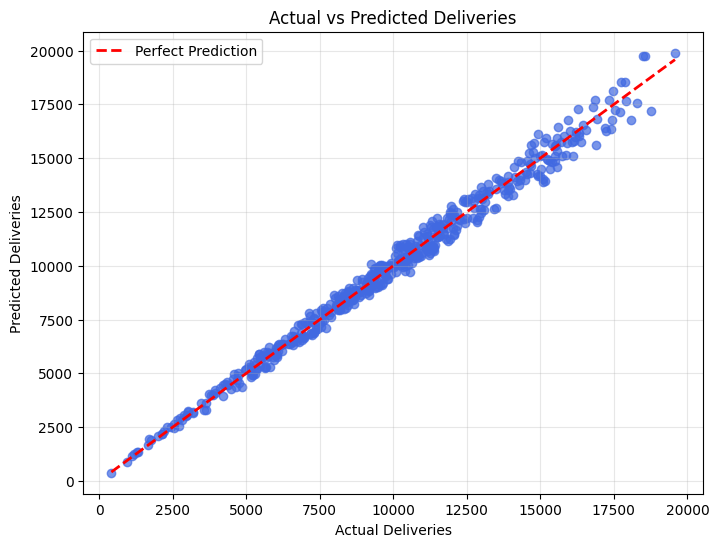

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.7,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

**Output Description:** The scatter plot compares the actual and predicted Tesla delivery values. Most data points lie close to the ideal diagonal trend, indicating that the Random Forest model produces highly accurate predictions with minimal prediction error. The close alignment between actual and predicted values confirms the model's strong predictive capability.

In [36]:
# 14. Time Series Forecasting

monthly_data = df.groupby("Date")["Estimated_Deliveries"].sum()

monthly_data = monthly_data.asfreq("MS")

ts_model = ExponentialSmoothing(
    monthly_data,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

ts_fit = ts_model.fit()

forecast = ts_fit.forecast(12)

forecast

2026-01-01    192502.753093
2026-02-01    190434.149581
2026-03-01    198069.542458
2026-04-01    189793.349012
2026-05-01    197735.854263
2026-06-01    192218.727443
2026-07-01    201204.877933
2026-08-01    208204.883594
2026-09-01    198373.419688
2026-10-01    203015.733352
2026-11-01    195869.454672
2026-12-01    206737.671885
Freq: MS, dtype: float64

**Output Description:** The Holt-Winters Exponential Smoothing model forecasts Tesla's estimated monthly vehicle deliveries for the next 12 months (January 2026 to December 2026). The forecast predicts monthly deliveries ranging from approximately 189,000 to 208,000 vehicles, indicating relatively stable demand with moderate seasonal fluctuations throughout the year.

**Interpretation**

The model predicts:
1. Lowest month ≈ 189,793 deliveries
2. Highest month ≈ 208,205 deliverie
This means Tesla deliveries are expected to remain stable, with only small seasonal variations.

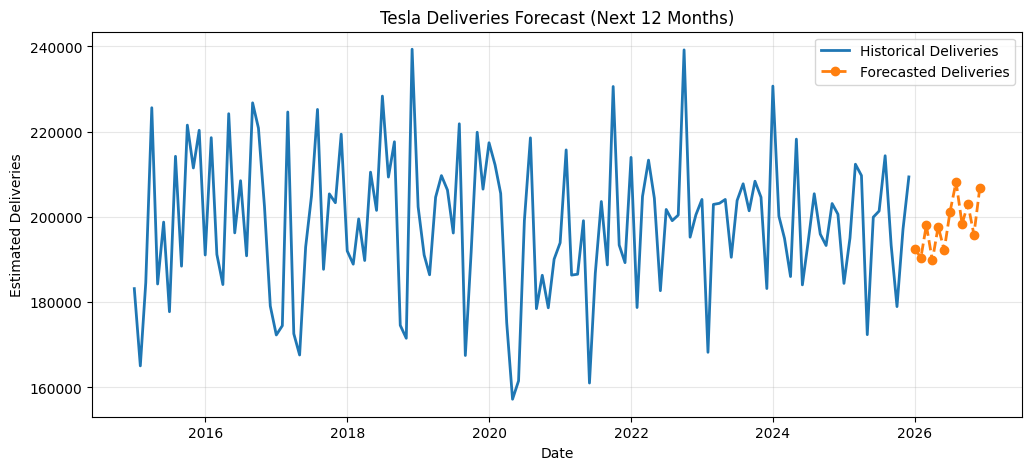

In [41]:
# Plot the Forecast
plt.figure(figsize=(12,5))

plt.plot(monthly_data.index,
         monthly_data.values,
         label="Historical Deliveries",
         linewidth=2)

plt.plot(forecast.index,
         forecast.values,
         label="Forecasted Deliveries",
         linewidth=2,
         linestyle="--",
         marker="o")

plt.title("Tesla Deliveries Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Output Description:** The line chart displays historical Tesla delivery data alongside the forecasted deliveries for the next 12 months. The forecast suggests that monthly deliveries will remain relatively stable with slight seasonal variations, indicating consistent production and demand trends during the forecast period.

In [38]:
# 16. Final Summary

print("Final ML Pipeline Completed Successfully")
print("Best Model: Random Forest Regressor")
print("Best Parameters:", grid.best_params_)
print("Final R2 Score:", r2_score(y_test, best_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("Forecast Generated For Next 12 Months")

Final ML Pipeline Completed Successfully
Best Model: Random Forest Regressor
Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Final R2 Score: 0.9886090407732363
Final RMSE: 412.06421872662173
Forecast Generated For Next 12 Months


**Output Description:** The end-to-end machine learning pipeline was successfully completed. After comparing multiple regression models and performing hyperparameter tuning, Random Forest Regressor was selected as the final model. The optimal configuration consisted of 100 decision trees, a maximum depth of 20, and a minimum split size of 5. The final model achieved an R² score of 0.9886 and an RMSE of 412.06, indicating excellent predictive performance. Additionally, a 12-month time series forecast was generated using the Holt-Winters Exponential Smoothing model to estimate future Tesla vehicle deliveries.

**Conclusion**

This project developed a complete end-to-end machine learning pipeline for predicting Tesla vehicle deliveries using historical production and sales data from 2015–2025.

**The workflow included:**

Data Loading and Inspection

Data Preprocessing

Exploratory Data Analysis (EDA)

Feature Engineering


Random Forest Regression

Hyperparameter Tuning using GridSearchCV

Feature Importance Analysis

Time Series Forecasting using Holt-Winters Exponential Smoothing

Among the evaluated models, Random Forest Regression produced the best predictive performance with an R² Score of 0.9886, demonstrating its ability to accurately capture the relationship between production, pricing, battery specifications, charging infrastructure, and Tesla vehicle deliveries.

The forecasting model predicted that monthly Tesla deliveries during 2026 would remain relatively stable, with moderate seasonal fluctuations, providing valuable insights into future delivery trends.

Overall, the developed pipeline demonstrates the effective application of machine learning techniques for sales prediction and time series forecasting, making it suitable for business decision-making and future demand analysis.